## Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
df=pd.read_csv('/content/StoreSales.csv')

In [3]:
df.head(4)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775


In [4]:
df = df.drop(columns=['Row ID'])

## Check Missing Values

In [5]:
df.isnull().sum()

,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0
State,0


In [6]:
df[df.isnull().any(axis=1)]

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
2234,CA-2018-104066,05/12/2018,10/12/2018,Standard Class,QJ-19255,Quincy Jones,Corporate,United States,Burlington,Vermont,NaN,East,TEC-AC-10001013,Technology,Accessories,Logitech ClearChat Comfort/USB Headset H390,205.03
5274,CA-2016-162887,07/11/2016,09/11/2016,Second Class,SV-20785,Stewart Visinsky,Consumer,United States,Burlington,Vermont,NaN,East,FUR-CH-10000595,Furniture,Chairs,Safco Contoured Stacking Chairs,715.20
8798,US-2017-150140,06/04/2017,10/04/2017,Standard Class,VM-21685,Valerie Mitchum,Home Office,United States,Burlington,Vermont,NaN,East,TEC-PH-10002555,Technology,Phones,Nortel Meridian M5316 Digital phone,1294.75
9146,US-2017-165505,23/01/2017,27/01/2017,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,NaN,East,TEC-AC-10002926,Technology,Accessories,Logitech Wireless Marathon Mouse M705,99.98
9147,US-2017-165505,23/01/2017,27/01/2017,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,NaN,East,OFF-AR-10003477,Office Supplies,Art,4009 Highlighters,8.04
9148,US-2017-165505,23/01/2017,27/01/2017,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,NaN,East,OFF-ST-10001526,Office Supplies,Storage,Iceberg Mobile Mega Data/Printer Cart,1564.29
9386,US-2018-127292,19/01/2018,23/01/2018,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-PA-10000157,Office Supplies,Paper,Xerox 191,79.92
9387,US-2018-127292,19/01/2018,23/01/2018,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-PA-10001970,Office Supplies,Paper,Xerox 1881,12.28
9388,US-2018-127292,19/01/2018,23/01/2018,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-AP-10000828,Office Supplies,Appliances,Avanti 4.4 Cu. Ft. Refrigerator,542.94
9389,US-2018-127292,19/01/2018,23/01/2018,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-EN-10001509,Office Supplies,Envelopes,Poly String Tie Envelopes,2.04


## Replace Missing Postal codes

In [7]:
df['Postal Code'] = df['Postal Code'].astype(str).str.replace('.0', '', regex=False)
df['Postal Code'] = df['Postal Code'].replace('nan', np.nan)
df.loc[(df['State'] == 'Vermont') & (df['City'] == 'Burlington'), 'Postal Code'] = '05401'
df['Postal Code'] = df['Postal Code'].str.zfill(5)

## Check Missing Values

In [8]:
df.isnull().sum()

,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0
State,0


## Check Duplicate Values

In [9]:
print(df.duplicated().sum())

1


## Check Data Types

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order ID       9800 non-null   object 
 1   Order Date     9800 non-null   object 
 2   Ship Date      9800 non-null   object 
 3   Ship Mode      9800 non-null   object 
 4   Customer ID    9800 non-null   object 
 5   Customer Name  9800 non-null   object 
 6   Segment        9800 non-null   object 
 7   Country        9800 non-null   object 
 8   City           9800 non-null   object 
 9   State          9800 non-null   object 
 10  Postal Code    9800 non-null   object 
 11  Region         9800 non-null   object 
 12  Product ID     9800 non-null   object 
 13  Category       9800 non-null   object 
 14  Sub-Category   9800 non-null   object 
 15  Product Name   9800 non-null   object 
 16  Sales          9800 non-null   float64
dtypes: float64(1), object(16)
memory usage: 1.3+ MB


The previous output showed that 'Order Date' and 'Ship Date' are currently object type, but they should be datetime objects for proper date-time analysis.

In [11]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d/%m/%Y')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order ID       9800 non-null   object        
 1   Order Date     9800 non-null   datetime64[ns]
 2   Ship Date      9800 non-null   datetime64[ns]
 3   Ship Mode      9800 non-null   object        
 4   Customer ID    9800 non-null   object        
 5   Customer Name  9800 non-null   object        
 6   Segment        9800 non-null   object        
 7   Country        9800 non-null   object        
 8   City           9800 non-null   object        
 9   State          9800 non-null   object        
 10  Postal Code    9800 non-null   object        
 11  Region         9800 non-null   object        
 12  Product ID     9800 non-null   object        
 13  Category       9800 non-null   object        
 14  Sub-Category   9800 non-null   object        
 15  Product Name   9800 n

## Check Uniqueness of Identifier Columns

In [12]:
print(f"Total number of rows: {df.shape[0]}")
print(f"Unique Order IDs: {df['Order ID'].nunique()}")
print(f"Unique Customer IDs: {df['Customer ID'].nunique()}")
print(f"Unique Product IDs: {df['Product ID'].nunique()}")

Total number of rows: 9800
Unique Order IDs: 4922
Unique Customer IDs: 793
Unique Product IDs: 1861


*   Order IDs (4,922) vs. Total Rows (9,800) meaning that most customers buy 2 items per order.

*   Product IDs a wide variety of products (1,861 items), but many are popular enough to be bought repeatedly.

*   Customer IDs (793) With 9,800 rows and only 793 customers, repeat purchase rate is very high. each customer shops here about 12 times, this suggests a loyal customer base or a subscription-like purchasing habit.

## Verify Date Logic
Confirm 'Ship Date' is always on or after 'Order Date'

In [13]:
incorrect_ship_dates = df[df['Ship Date'] < df['Order Date']]
print(f"Number of records where Ship Date is before Order Date: {incorrect_ship_dates.shape[0]}")

Number of records where Ship Date is before Order Date: 0


## Inspect Categorical Columns

Examining the unique values in categorical columns helps uncover potential data entry errors, misspellings, or inconsistent formatting

In [14]:
categorical_columns = ['Category', 'Sub-Category', 'Segment', 'Region', 'Ship Mode']

for col in categorical_columns:
    print(f"Unique values for '{col}':")
    print(df[col].unique())
    print("\n")

Unique values for 'Category':
['Furniture' 'Office Supplies' 'Technology']


Unique values for 'Sub-Category':
['Bookcases' 'Chairs' 'Labels' 'Tables' 'Storage' 'Furnishings' 'Art'
 'Phones' 'Binders' 'Appliances' 'Paper' 'Accessories' 'Envelopes'
 'Fasteners' 'Supplies' 'Machines' 'Copiers']


Unique values for 'Segment':
['Consumer' 'Corporate' 'Home Office']


Unique values for 'Region':
['South' 'West' 'Central' 'East']


Unique values for 'Ship Mode':
['Second Class' 'Standard Class' 'First Class' 'Same Day']




In [15]:
categorical_columns = ['Category', 'Sub-Category', 'Segment', 'Region', 'Ship Mode']

for col in categorical_columns:
    print(f"--- Frequency Distribution for '{col}' ---")
    print(df[col].value_counts())
    print("\n")

--- Frequency Distribution for 'Category' ---
Category
Office Supplies    5909
Furniture          2078
Technology         1813
Name: count, dtype: int64


--- Frequency Distribution for 'Sub-Category' ---
Sub-Category
Binders        1492
Paper          1338
Furnishings     931
Phones          876
Storage         832
Art             785
Accessories     756
Chairs          607
Appliances      459
Labels          357
Tables          314
Envelopes       248
Bookcases       226
Fasteners       214
Supplies        184
Machines        115
Copiers          66
Name: count, dtype: int64


--- Frequency Distribution for 'Segment' ---
Segment
Consumer       5101
Corporate      2953
Home Office    1746
Name: count, dtype: int64


--- Frequency Distribution for 'Region' ---
Region
West       3140
East       2785
Central    2277
South      1598
Name: count, dtype: int64


--- Frequency Distribution for 'Ship Mode' ---
Ship Mode
Standard Class    5859
Second Class      1902
First Class       1501
Same

## **Exploratory Data Analysis (EDA)**

In [16]:
df['Sales'].describe()

,Sales
count,9800.000000
mean,230.769059
std,626.651875
min,0.444000
25%,17.248000
50%,54.490000
75%,210.605000
max,22638.480000


## Sales Distribution

In [17]:
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_sales = df[(df['Sales'] < lower_bound) | (df['Sales'] > upper_bound)]

print(f"Number of outliers in 'Sales' (using IQR method): {outliers_sales.shape[0]}")
print(f"Lower bound for outliers: {lower_bound:.2f}")
print(f"Upper bound for outliers: {upper_bound:.2f}")

Number of outliers in 'Sales' (using IQR method): 1145
Lower bound for outliers: -272.79
Upper bound for outliers: 500.64


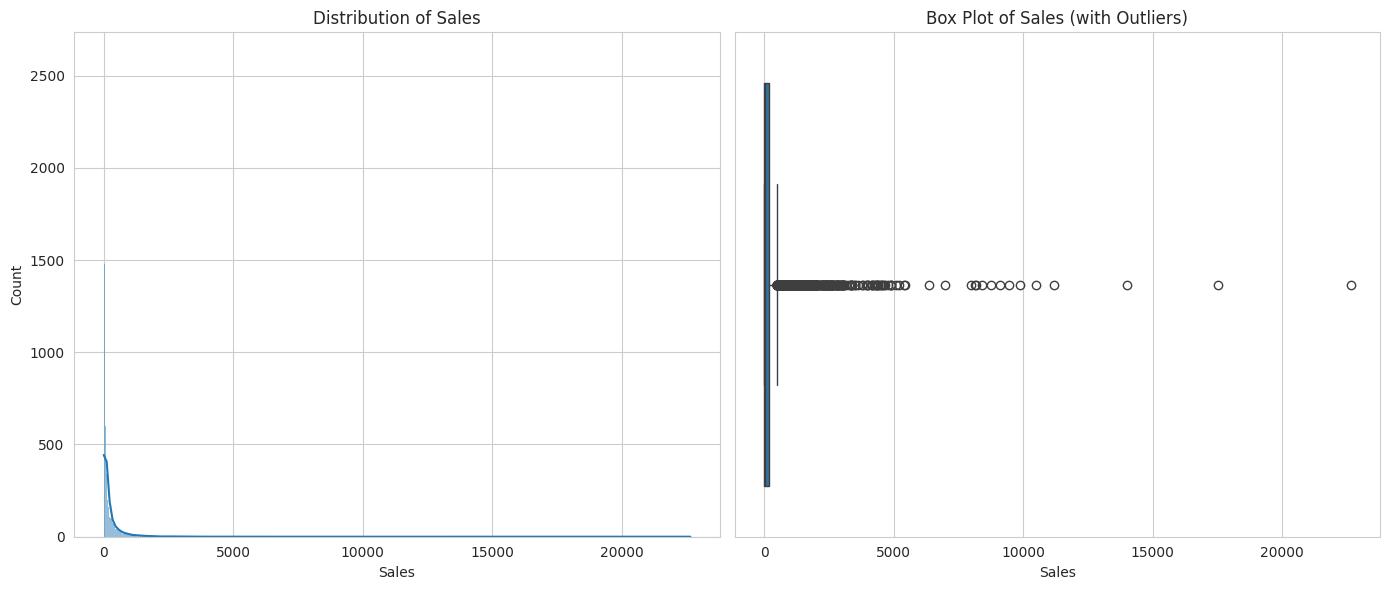

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.histplot(df['Sales'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of Sales')
axes[0].set_xlabel('Sales')

sns.boxplot(x=df['Sales'], ax=axes[1])
axes[1].set_title('Box Plot of Sales (with Outliers)')
axes[1].set_xlabel('Sales')

plt.tight_layout()
plt.show()



*   Non-Normal Distribution: The sales data is heavily right-skewed, meaning standard average-based metrics (like Mean) will be misleading. The Median ($54.49) is a much better representation of a "typical" sale.

*   Significant Outliers: Both the distribution and box plots confirm a high frequency of outlier transactions.

*   Business Insight: There is a clear distinction between "Everyday" small-ticket orders and "Whale" high-value orders.


In [19]:
df['Ship_Days'] = (df['Ship Date'] - df['Order Date']).dt.days

## Correlation Analysis: Sales vs Shipping Time

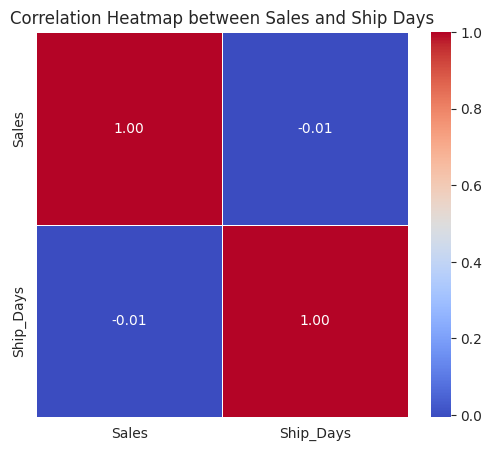

In [20]:
correlation = df[['Sales', 'Ship_Days']].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap between Sales and Ship Days')
plt.show()

correlation is near zero, meaning price doesn't affect shipping time. High-value orders don't get "special treatment", they move through the same logistics process as everything else

## Outlier Sales by Category

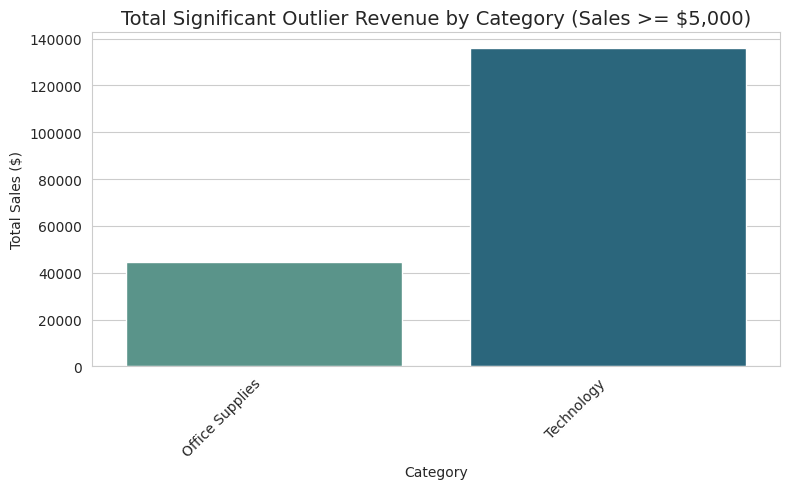

In [21]:
outliers = df[df['Sales'] >= 5000]
category_outliers = outliers.groupby('Category')['Sales'].agg(['count', 'sum', 'mean'])

plt.figure(figsize=(8, 5))
sns.barplot(
    x=category_outliers.index,
    y=category_outliers['sum'],
    hue=category_outliers.index,
    palette='crest',
    legend=False)

plt.title('Total Significant Outlier Revenue by Category (Sales >= $5,000)', fontsize=14)
plt.xlabel('Category')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Technology is the primary factor, driving nearly 3x more outlier revenue than Office Supplies

## **Top 5 Specific Outlier Products**

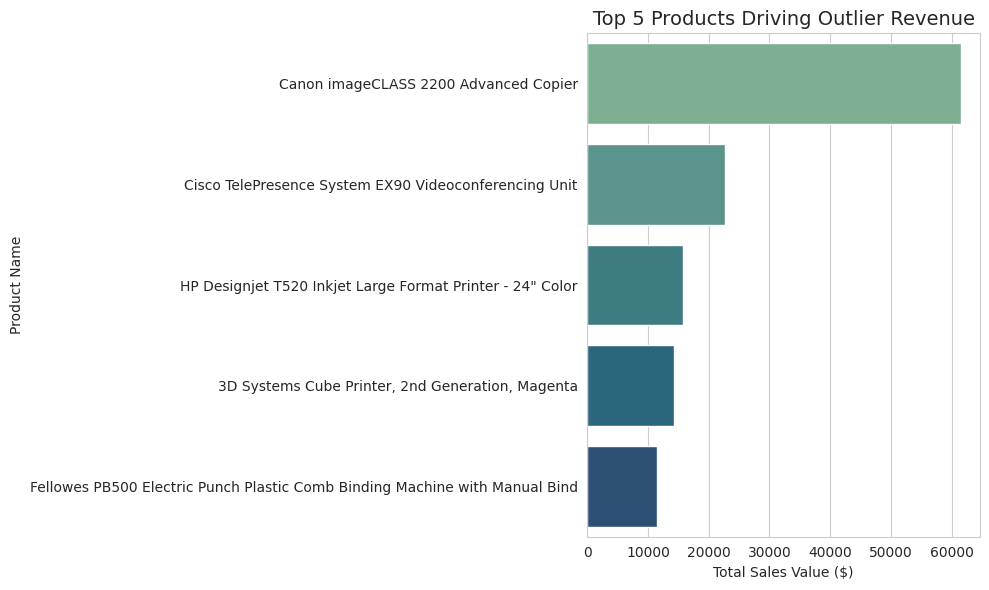

In [22]:
top_products = outliers.groupby('Product Name')['Sales'].sum().nlargest(5)

top_products_df = top_products.reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_products_df,
    x='Sales',
    y='Product Name',
    hue='Product Name',
    palette='crest',
    legend=False)

plt.title('Top 5 Products Driving Outlier Revenue', fontsize=14)
plt.xlabel('Total Sales Value ($)')
plt.ylabel('Product Name')
plt.tight_layout()
plt.show()

## Total Sales by Category

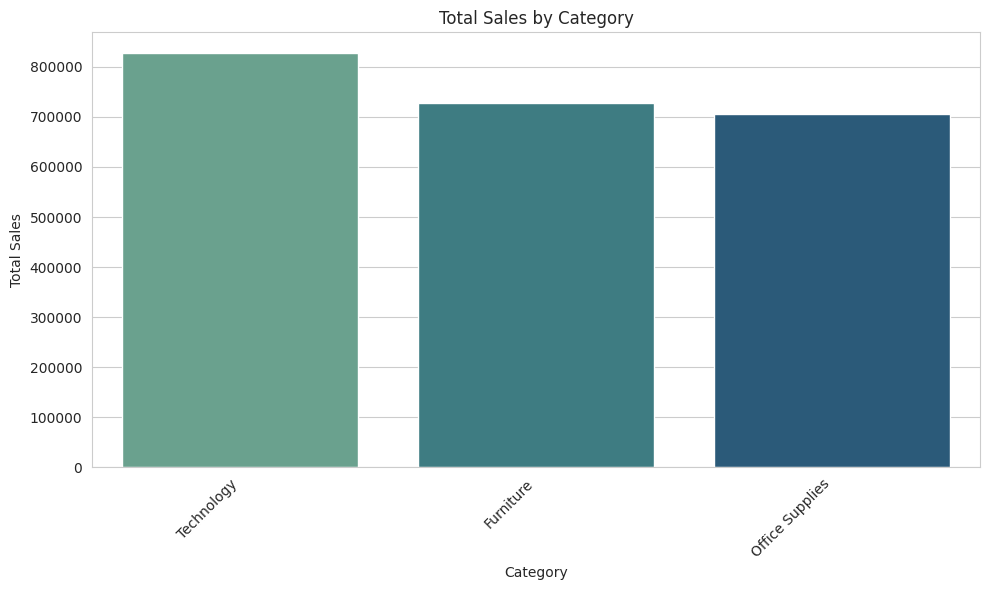

In [23]:
sales_by_category = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=sales_by_category.index, y=sales_by_category.values, hue=sales_by_category.index, palette='crest', legend=False)
plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Total Sales by Sub-Category

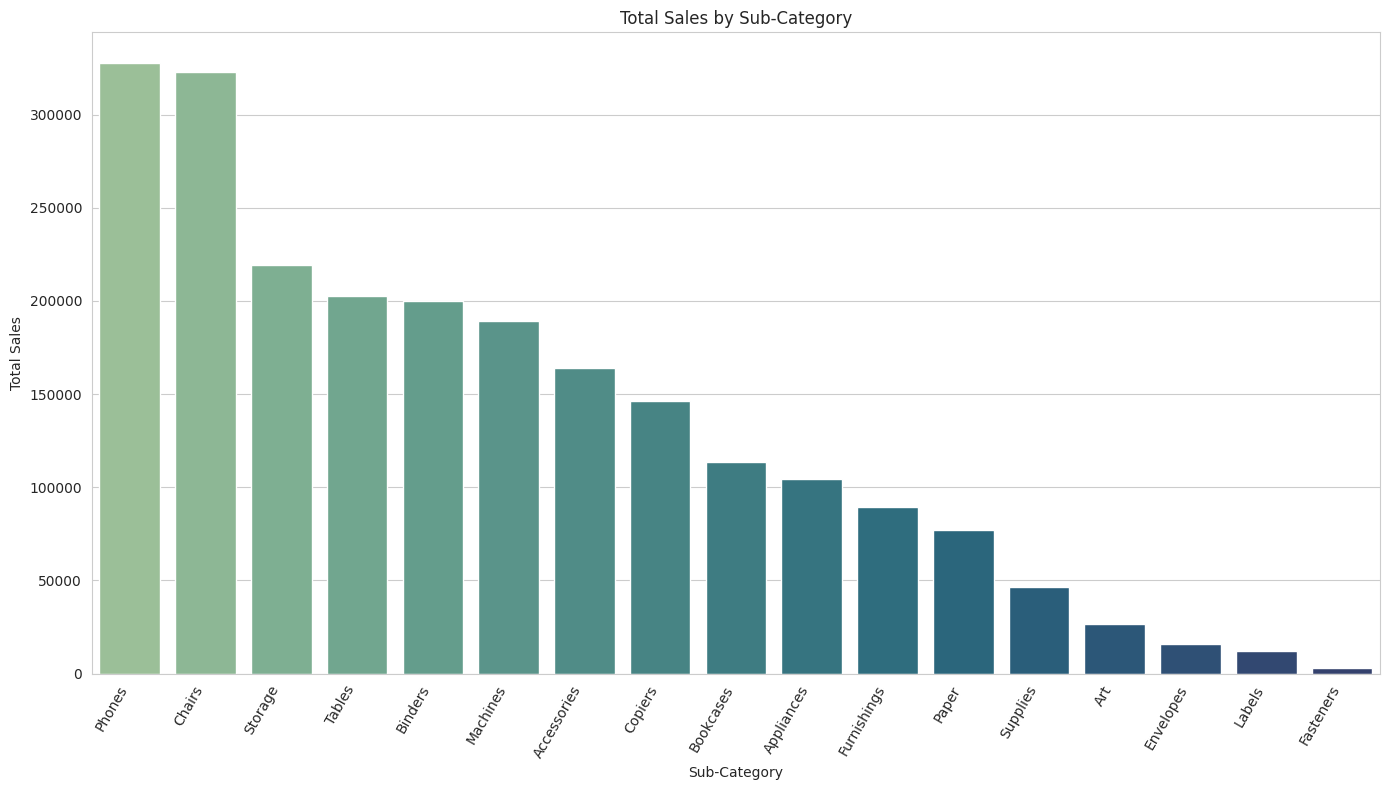

In [24]:
sales_by_sub_category = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(14, 8))
sns.barplot(x=sales_by_sub_category.index, y=sales_by_sub_category.values, hue=sales_by_sub_category.index, palette='crest', legend=False)
plt.title('Total Sales by Sub-Category')
plt.xlabel('Sub-Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

## Total Sales by Segment

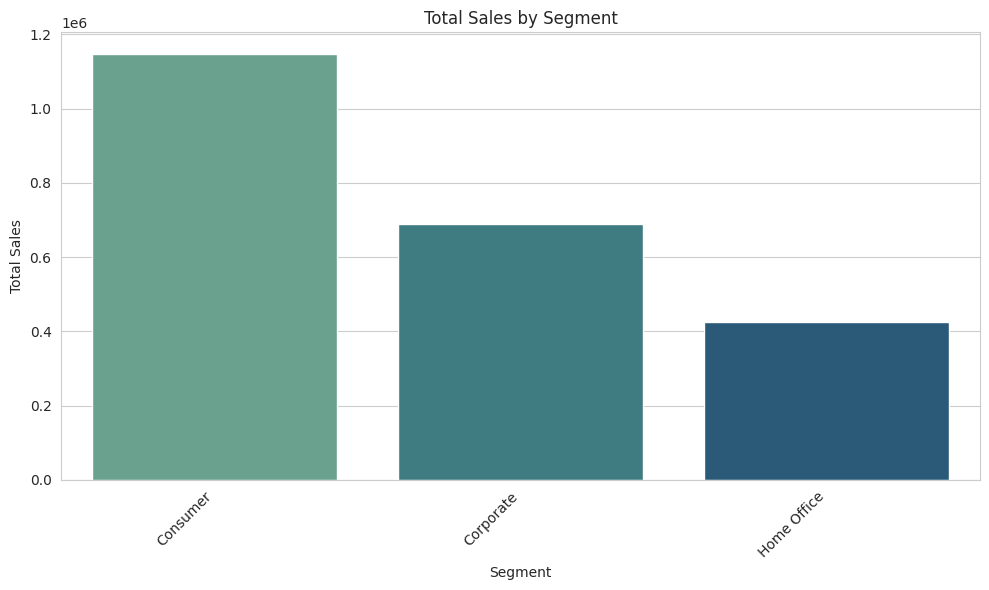

In [25]:
sales_by_segment = df.groupby('Segment')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=sales_by_segment.index, y=sales_by_segment.values, hue=sales_by_segment.index, palette='crest', legend=False)
plt.title('Total Sales by Segment')
plt.xlabel('Segment')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Total Sales by Region

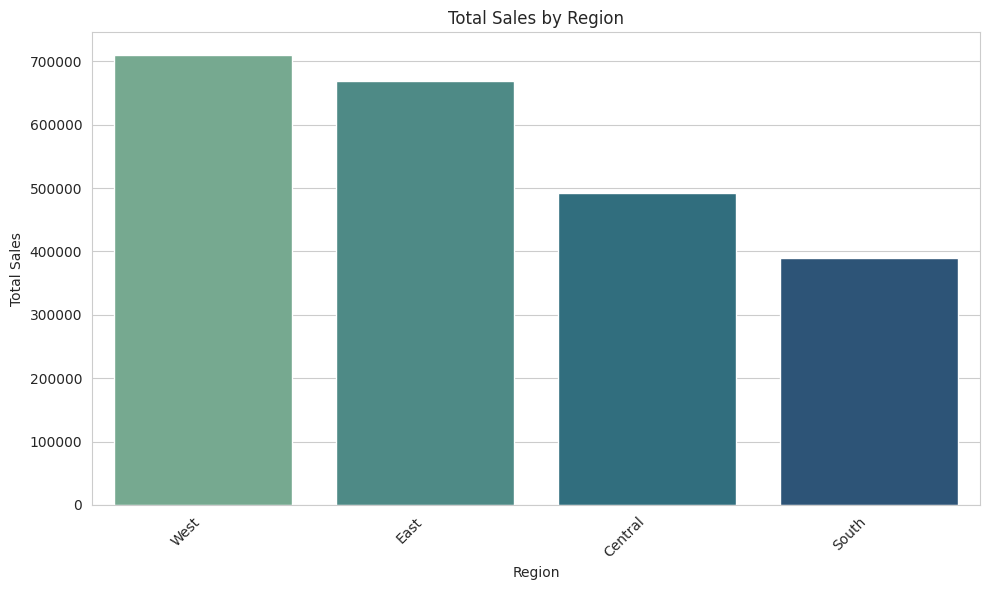

In [26]:
sales_by_region = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=sales_by_region.index, y=sales_by_region.values, hue=sales_by_region.index, palette='crest', legend=False)
plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## **Total Sales Over Time**

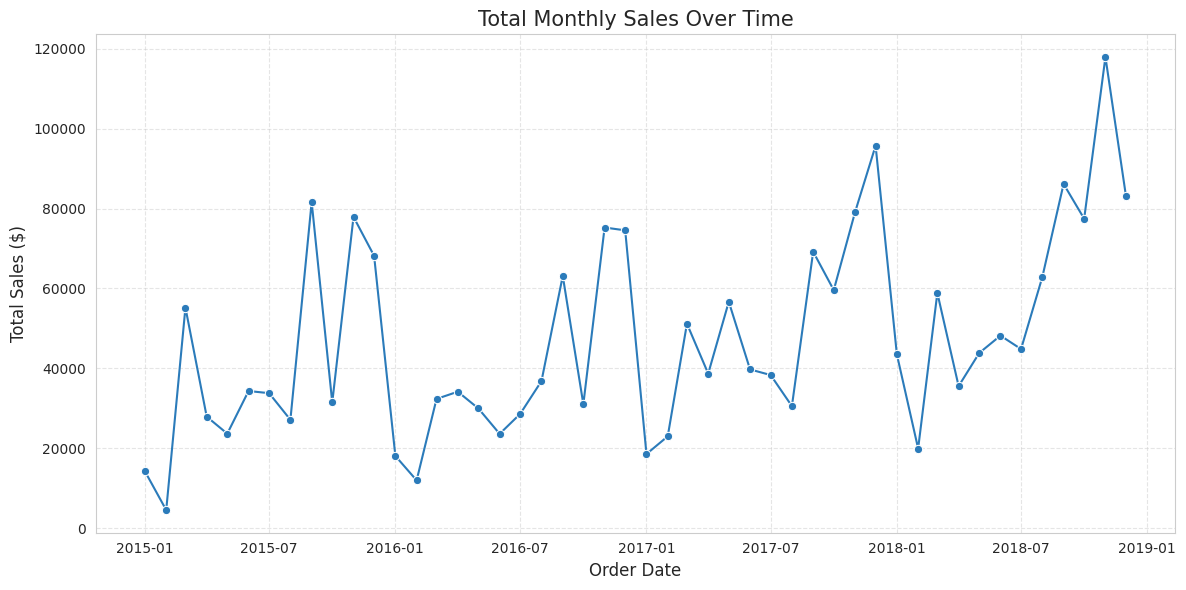

In [27]:
sales_monthly = df.resample('MS', on='Order Date')['Sales'].sum()

plt.figure(figsize=(12, 6))
sns.lineplot(x=sales_monthly.index, y=sales_monthly.values, marker='o', color='#2b7bba')

plt.title('Total Monthly Sales Over Time', fontsize=15)
plt.xlabel('Order Date', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Export the Cleaned Dataset

In [29]:
df.to_csv('SalesPerformance_Processed.csv', index=False)